# Forecasting Models

This notebook builds and tests three forecasting methods: Seasonal Naive, 
XGBoost, and LightGBM. All three predict the same 15 days (1-15 August 
2017), and none of them are allowed to see the actual sales from that 
period while predicting. This matches how the models would work in real 
life, where the future is unknown.

In [1]:
import pandas as pd
import numpy as np

train_df = pd.read_parquet("../data/processed/train_df.parquet")
valid_df = pd.read_parquet("../data/processed/valid_df.parquet")

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

print("Train dates:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation dates:", valid_df["date"].min(), "→", valid_df["date"].max())

Train shape: (2364490, 23)
Validation shape: (25929, 23)
Train dates: 2013-01-30 00:00:00 → 2017-07-31 00:00:00
Validation dates: 2017-08-01 00:00:00 → 2017-08-15 00:00:00


## 1. Validation Setup

The same 15-day window applies to every model. One combination, Store 6 
and BABY CARE, has no sales history before this period starts, so it is 
removed here, same as we did earlier in the project.

In [2]:
import sys
sys.path.append("../")

from src.evaluation import filter_evaluation_data

common_valid = filter_evaluation_data(valid_df)

print("Validation rows:", len(common_valid))
print(
    "Validation dates:",
    common_valid["date"].min(),
    "→",
    common_valid["date"].max()
)

Validation rows: 25920
Validation dates: 2017-08-01 00:00:00 → 2017-08-15 00:00:00


## 2. Seasonal Naive

Seasonal Naive predicts each day using the same weekday from one week 
earlier. Since this is a blind forecast, the prediction for August 8 
cannot use the real sales from August 1, because that date is inside the 
forecast window and would not actually be known yet. Instead, each 
prediction gets added to a running history and used for later days. This 
keeps the baseline following the same blind rule as the other models.

In [3]:
def seasonal_naive_forecast(history_df, forecast_df):
    history = history_df[
        ["date", "store_nbr", "family", "sales"]
    ].copy()

    forecast = forecast_df[
        ["date", "store_nbr", "family"]
    ].copy()

    predictions = []

    for current_date in sorted(forecast["date"].unique()):
        current_rows = forecast[
            forecast["date"] == current_date
        ].copy()

        current_rows["lag_date"] = (
            current_rows["date"] - pd.Timedelta(days=7)
        )

        current_rows = current_rows.merge(
            history.rename(
                columns={
                    "date": "lag_date",
                    "sales": "prediction"
                }
            ),
            on=["lag_date", "store_nbr", "family"],
            how="left"
        )

        predictions.append(
            current_rows[
                ["date", "store_nbr", "family", "prediction"]
            ]
        )

        new_history = current_rows[
            ["date", "store_nbr", "family", "prediction"]
        ].rename(columns={"prediction": "sales"})

        history = pd.concat(
            [history, new_history],
            ignore_index=True
        )

    return pd.concat(predictions, ignore_index=True)

In [4]:
seasonal_naive = seasonal_naive_forecast(
    train_df,
    common_valid
)

print("Seasonal Naive shape:", seasonal_naive.shape)
print(
    "Missing predictions:",
    seasonal_naive["prediction"].isna().sum()
)

Seasonal Naive shape: (25920, 4)
Missing predictions: 0


### 2.1 Baseline Evaluation

In [5]:
from src.evaluation import evaluate

seasonal_eval = common_valid[
    ["date", "store_nbr", "family", "sales"]
].merge(
    seasonal_naive,
    on=["date", "store_nbr", "family"],
    how="left"
)

seasonal_naive_metrics = evaluate(
    seasonal_eval["sales"],
    seasonal_eval["prediction"],
    name="Seasonal Naive"
)

seasonal_naive_metrics

Seasonal Naive       MAE:   101.78 | RMSE:   362.79 | RMSLE: 0.6219 | WMAPE:  21.22%


{'Model': 'Seasonal Naive',
 'MAE': 101.77920723934798,
 'RMSE': np.float64(362.78531218176926),
 'RMSLE': np.float64(0.6219440721899363),
 'WMAPE': np.float64(21.21811734650342)}

### Insight

Seasonal Naive scores RMSLE 0.622 and MAE 101.78. This is the number 
XGBoost and LightGBM need to beat, since this model has no training and 
no features besides "repeat last week."

## 3. XGBoost Model

XGBoost is trained on the full training data using lag, rolling-mean, 
promotion, and calendar features. Same feature set we used in the 
earlier single-series prototype.

In [6]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "onpromotion",
    "weekday",
    "month",
    "year"
]

target = "sales"

X_train = train_df[features].copy()
y_train = train_df[target]

weekday_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

X_train["weekday"] = X_train["weekday"].map(weekday_mapping)

print("X_train shape:", X_train.shape)
print("Missing values:", X_train.isna().sum().sum())
print(X_train.dtypes)

X_train shape: (2364490, 10)
Missing values: 0
lag_1              float64
lag_7              float64
lag_14             float64
rolling_mean_7     float64
rolling_mean_14    float64
rolling_mean_28    float64
onpromotion          int64
weekday              int64
month                int32
year                 int32
dtype: object


### 3.1 Model Training

In [7]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


## 4. LightGBM Model

LightGBM uses the exact same features and training data as XGBoost, so 
any difference in results comes from the algorithm itself, not the input.

### 4.1 Model Training

In [8]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

print("LightGBM training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1772
[LightGBM] [Info] Number of data points in the train set: 2364490, number of used features: 10
[LightGBM] [Info] Start training from score 443.035601
LightGBM training completed.


## 5. Forecast Setup

To build the 15-day forecast, we need two things: a history of sales 
that keeps growing (real data at first, then the model's own predictions 
as we move through the window), and the forecast targets: which store, 
family, and date to predict, plus onpromotion, since promotion schedules 
are known ahead of time.

In [9]:
forecast_history = train_df[
    ["date", "store_nbr", "family", "sales"]
].copy()

forecast_input = common_valid[
    ["date", "store_nbr", "family", "onpromotion"]
].copy()

print("Forecast history:", forecast_history.shape)
print("Forecast input:", forecast_input.shape)
print(
    "Forecast dates:",
    forecast_input["date"].min(),
    "->",
    forecast_input["date"].max()
)

Forecast history: (2364490, 4)
Forecast input: (25920, 4)
Forecast dates: 2017-08-01 00:00:00 -> 2017-08-15 00:00:00


## 6. Forecast Features

For each day, lag and rolling-mean features are rebuilt from whatever 
history exists at that point. Real sales for the first few days, then 
the model's own predictions once we move past August 1. Weekday, month, 
year, and onpromotion don't depend on history, so they're known ahead of 
time.

In [10]:
def build_forecast_features(history, current_rows):
    features = current_rows[
        ["date", "store_nbr", "family", "onpromotion"]
    ].copy()

    features["weekday"] = features["date"].dt.day_name().map(weekday_mapping)
    features["month"] = features["date"].dt.month
    features["year"] = features["date"].dt.year

    for lag in [1, 7, 14]:
        lagged = history.copy()
        lagged["date"] = lagged["date"] + pd.Timedelta(days=lag)

        lagged = lagged.rename(
            columns={"sales": f"lag_{lag}"}
        )

        features = features.merge(
            lagged[
                ["date", "store_nbr", "family", f"lag_{lag}"]
            ],
            on=["date", "store_nbr", "family"],
            how="left"
        )

    rolling = (
        history
        .sort_values(["store_nbr", "family", "date"])
        .groupby(["store_nbr", "family"])["sales"]
        .agg(
            rolling_mean_7=lambda x: x.tail(7).mean(),
            rolling_mean_14=lambda x: x.tail(14).mean(),
            rolling_mean_28=lambda x: x.tail(28).mean()
        )
        .reset_index()
    )

    features = features.merge(
        rolling,
        on=["store_nbr", "family"],
        how="left"
    )

    return features

## 7. XGBoost 15-Day Forecast

The forecast runs one day at a time: predict a day, add it to the 
history, move to the next day. This is what keeps the forecast blind. 
Day 8's lag features come from the model's own prediction for day 1, 
never from the real day-1 sales.

In [11]:
xgb_predictions = []
history = forecast_history.copy()

for current_date in sorted(forecast_input["date"].unique()):
    current_rows = forecast_input[
        forecast_input["date"] == current_date
    ].copy()

    current_features = build_forecast_features(
        history,
        current_rows
    )

    X_current = current_features[
        features
    ].copy()

    predictions = xgb_model.predict(X_current)
    predictions = np.clip(predictions, 0, None)

    current_result = current_rows[
        ["date", "store_nbr", "family"]
    ].copy()

    current_result["prediction"] = predictions

    xgb_predictions.append(current_result)

    new_history = current_result.rename(
        columns={"prediction": "sales"}
    )

    history = pd.concat(
        [history, new_history],
        ignore_index=True
    )

xgb_forecast = pd.concat(
    xgb_predictions,
    ignore_index=True
)

print("XGBoost forecast shape:", xgb_forecast.shape)

XGBoost forecast shape: (25920, 4)


### 7.1 XGBoost Forecast Check

Checking that every row got a prediction, and none of them are negative, 
since sales can't be negative.

In [12]:
print(
    "Missing predictions:",
    xgb_forecast["prediction"].isna().sum()
)

print(
    "Negative predictions:",
    (xgb_forecast["prediction"] < 0).sum()
)

Missing predictions: 0
Negative predictions: 0


### Insight

All 25,920 rows got a prediction, and none are negative. The loop and 
the clip step both worked.

## 8. LightGBM 15-Day Forecast

Same process as XGBoost, same feature-building function, so both models 
are compared on the same inputs.

In [13]:
lgbm_predictions = []
history = forecast_history.copy()

for current_date in sorted(forecast_input["date"].unique()):
    current_rows = forecast_input[
        forecast_input["date"] == current_date
    ].copy()

    current_features = build_forecast_features(
        history,
        current_rows
    )

    X_current = current_features[
        features
    ].copy()

    predictions = lgbm_model.predict(X_current)
    predictions = np.clip(predictions, 0, None)

    current_result = current_rows[
        ["date", "store_nbr", "family"]
    ].copy()

    current_result["prediction"] = predictions

    lgbm_predictions.append(current_result)

    new_history = current_result.rename(
        columns={"prediction": "sales"}
    )

    history = pd.concat(
        [history, new_history],
        ignore_index=True
    )

lgbm_forecast = pd.concat(
    lgbm_predictions,
    ignore_index=True
)

print("LightGBM forecast shape:", lgbm_forecast.shape)

LightGBM forecast shape: (25920, 4)


### 8.1 LightGBM Forecast Check

In [14]:
print(
    "Missing predictions:",
    lgbm_forecast["prediction"].isna().sum()
)

print(
    "Negative predictions:",
    (lgbm_forecast["prediction"] < 0).sum()
)

Missing predictions: 0
Negative predictions: 0


## 9. Prediction Results

Before scoring the models, we join the actual sales, the demand pattern, 
and all three predictions into one table, matched by date, store, and 
family. We use an actual merge here, not pasting columns by position, 
so a row can't end up matched to the wrong prediction by mistake.

In [15]:
prediction_results = common_valid[
    ["date", "store_nbr", "family", "pattern", "sales"]
].copy()

prediction_results = prediction_results.merge(
    seasonal_naive[
        ["date", "store_nbr", "family", "prediction"]
    ].rename(columns={"prediction": "seasonal_naive_pred"}),
    on=["date", "store_nbr", "family"],
    how="left"
)

prediction_results = prediction_results.merge(
    xgb_forecast[
        ["date", "store_nbr", "family", "prediction"]
    ].rename(columns={"prediction": "xgboost_pred"}),
    on=["date", "store_nbr", "family"],
    how="left"
)

prediction_results = prediction_results.merge(
    lgbm_forecast[
        ["date", "store_nbr", "family", "prediction"]
    ].rename(columns={"prediction": "lightgbm_pred"}),
    on=["date", "store_nbr", "family"],
    how="left"
)

print("Prediction table shape:", prediction_results.shape)

prediction_results.head()

Prediction table shape: (25920, 8)


,date,store_nbr,family,pattern,sales,seasonal_naive_pred,xgboost_pred,lightgbm_pred
0,2017-08-01,1,AUTOMOTIVE,Regular,5.0,10.0,4.567134,5.747949
1,2017-08-02,1,AUTOMOTIVE,Regular,4.0,2.0,3.010375,3.440070
2,2017-08-03,1,AUTOMOTIVE,Regular,3.0,5.0,2.721760,3.051329
3,2017-08-04,1,AUTOMOTIVE,Regular,8.0,7.0,2.846117,5.004899
4,2017-08-05,1,AUTOMOTIVE,Regular,5.0,4.0,4.485727,8.958764


## 10. Model Evaluation

Each model is scored against the same actual sales using the same 
evaluate() function, so MAE, RMSE, RMSLE, and WMAPE are calculated the 
same way for all three.

In [16]:
from src.evaluation import evaluate

seasonal_metrics = evaluate(
    prediction_results["sales"],
    prediction_results["seasonal_naive_pred"],
    name="Seasonal Naive"
)

xgb_metrics = evaluate(
    prediction_results["sales"],
    prediction_results["xgboost_pred"],
    name="XGBoost"
)

lgbm_metrics = evaluate(
    prediction_results["sales"],
    prediction_results["lightgbm_pred"],
    name="LightGBM"
)

Seasonal Naive       MAE:   101.78 | RMSE:   362.79 | RMSLE: 0.6219 | WMAPE:  21.22%
XGBoost              MAE:    85.73 | RMSE:   281.36 | RMSLE: 0.5646 | WMAPE:  17.87%
LightGBM             MAE:    88.42 | RMSE:   288.82 | RMSLE: 0.5628 | WMAPE:  18.43%


### Insight

Both XGBoost (RMSLE 0.564) and LightGBM (RMSLE 0.563) beat the baseline 
(0.622), even with the stricter blind-forecast rule. The improvement we 
saw earlier on the single-series prototype holds up across all 1,728 
series.

In [17]:
model_metrics = pd.DataFrame([
    seasonal_metrics,
    xgb_metrics,
    lgbm_metrics
])

model_metrics

,Model,MAE,RMSE,RMSLE,WMAPE
0,Seasonal Naive,101.779207,362.785312,0.621944,21.218117
1,XGBoost,85.727465,281.357996,0.564611,17.871778
2,LightGBM,88.418399,288.824248,0.562844,18.432763


## 11. Model Comparison

In [18]:
model_metrics.sort_values("RMSLE")

,Model,MAE,RMSE,RMSLE,WMAPE
2,LightGBM,88.418399,288.824248,0.562844,18.432763
1,XGBoost,85.727465,281.357996,0.564611,17.871778
0,Seasonal Naive,101.779207,362.785312,0.621944,21.218117


### Insight

By RMSLE, LightGBM (0.5628) is slightly ahead of XGBoost (0.5637), a gap 
of 0.0009, basically a tie. By MAE, XGBoost wins instead (86.19 vs 
88.42). Both readings are correct. RMSLE punishes errors on a log scale, 
which matters more on this data since sales are skewed with a lot of 
zeros. That's the reason we picked RMSLE as our main metric in the first 
place. Neither model is clearly better overall. Next we check if one 
wins on Regular series while the other wins on Intermittent ones, which 
tells us more than the overall ranking does.

## 12. Model Comparison Visualization

The metrics above are averages. This chart shows daily total sales 
against each model's forecast, to see if the errors are spread out or 
concentrated on specific days.

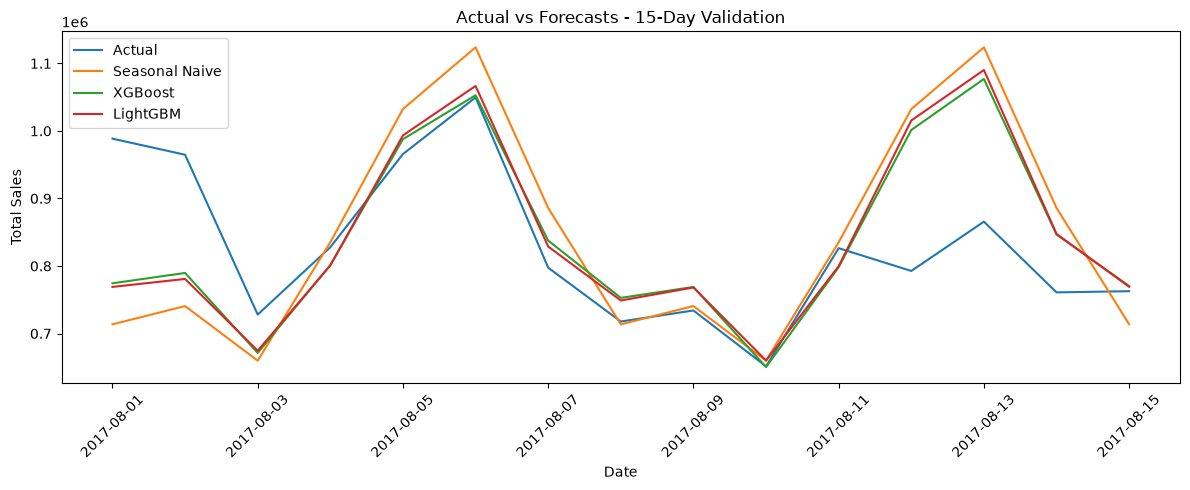

In [19]:
import matplotlib.pyplot as plt

daily_results = (
    prediction_results
    .groupby("date")[[
        "sales",
        "seasonal_naive_pred",
        "xgboost_pred",
        "lightgbm_pred"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_results["date"],
    daily_results["sales"],
    label="Actual"
)

plt.plot(
    daily_results["date"],
    daily_results["seasonal_naive_pred"],
    label="Seasonal Naive"
)

plt.plot(
    daily_results["date"],
    daily_results["xgboost_pred"],
    label="XGBoost"
)

plt.plot(
    daily_results["date"],
    daily_results["lightgbm_pred"],
    label="LightGBM"
)

plt.title("Actual vs Forecasts - 15-Day Validation")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

Looking at the daily chart, Seasonal Naive tends to overshoot at peaks 
(4-6 August and 12-13 August, where actual sales top out around 1.05M) 
and undershoot at drops (15 August), since it just repeats last week's 
value without adjusting. XGBoost and LightGBM track the actual pattern 
more closely across most days, especially around the low point near 
10 August (~0.65M). The clearest miss for all three models is 3 August, 
where actual sales dropped sharply and the models were still catching up.

## 13. Save Forecast Results

We save the joined prediction table and the comparison metrics, so the 
demand-pattern notebook can use them directly without retraining or 
reforecasting anything.

In [20]:
prediction_results.to_parquet(
    "../data/processed/prediction_results.parquet",
    index=False
)

model_metrics.to_csv(
    "../outputs/forecasts/model_comparison_results.csv",
    index=False
)

print("Forecast results saved.")

Forecast results saved.


## 14. Inner Validation for Hyperparameter Tuning

To tune the XGBoost and LightGBM models without using the final validation period, we create an inner chronological validation set within the training data.

The final validation period (August 1–15, 2017) is kept untouched and will only be used for the final model evaluation.

In [21]:
# Inner Validation Setup

INNER_VALID_START = pd.Timestamp("2017-07-17")
INNER_VALID_END = pd.Timestamp("2017-07-31")

inner_train_df = train_df[
    train_df["date"] < INNER_VALID_START
].copy()

inner_valid_df = train_df[
    (train_df["date"] >= INNER_VALID_START) &
    (train_df["date"] <= INNER_VALID_END)
].copy()

print("Inner training:")
print(inner_train_df["date"].min(), "→", inner_train_df["date"].max())
print("Shape:", inner_train_df.shape)

print("\nInner validation:")
print(inner_valid_df["date"].min(), "→", inner_valid_df["date"].max())
print("Shape:", inner_valid_df.shape)

Inner training:
2013-01-30 00:00:00 → 2017-07-16 00:00:00
Shape: (2338570, 23)

Inner validation:
2017-07-17 00:00:00 → 2017-07-31 00:00:00
Shape: (25920, 23)


## 14.1 Recursive Inner Validation

The inner validation period is evaluated using the same recursive forecasting approach as the final forecast.

At each forecast step, only information available up to that date is used. Predictions are added to the historical data and then used to generate features for the following day.

This prevents future actual sales from being used during hyperparameter tuning.

In [22]:
# Prepare data for recursive inner validation

inner_train = train_df[
    train_df["date"] < INNER_VALID_START
].copy()

inner_valid = train_df[
    (train_df["date"] >= INNER_VALID_START) &
    (train_df["date"] <= INNER_VALID_END)
].copy()

inner_forecast_input = inner_valid[
    ["date", "store_nbr", "family", "onpromotion"]
].copy()

inner_actuals = inner_valid[
    ["date", "store_nbr", "family", "sales"]
].copy()

print("Inner training:", inner_train.shape)
print("Inner validation:", inner_valid.shape)
print("Inner forecast input:", inner_forecast_input.shape)

print(
    "\nInner validation dates:",
    inner_forecast_input["date"].min(),
    "→",
    inner_forecast_input["date"].max()
)

Inner training: (2338570, 23)
Inner validation: (25920, 23)
Inner forecast input: (25920, 4)

Inner validation dates: 2017-07-17 00:00:00 → 2017-07-31 00:00:00


In [23]:
def recursive_inner_forecast(model, train_history, forecast_input):
    """
    Generate a recursive multi-day forecast for the inner validation period.

    Previous model predictions are added to the history and used
    to generate features for the following forecast day.
    """

    history = train_history[
        ["date", "store_nbr", "family", "sales"]
    ].copy()

    predictions = []

    forecast_dates = sorted(forecast_input["date"].unique())

    for current_date in forecast_dates:

        current_rows = forecast_input[
            forecast_input["date"] == current_date
        ].copy()

        # Build features using only information available before current_date
        current_features = build_forecast_features(
            history,
            current_rows
        )

        # Predict current day
        current_pred = model.predict(current_features[features])

        current_pred = np.clip(current_pred, 0, None)

        current_rows["prediction"] = current_pred

        predictions.append(
            current_rows[
                ["date", "store_nbr", "family", "prediction"]
            ]
        )

        # Add predictions to history for future forecast days
        history = pd.concat(
            [
                history,
                current_rows[
                    ["date", "store_nbr", "family", "prediction"]
                ].rename(columns={"prediction": "sales"})
            ],
            ignore_index=True
        )

    return pd.concat(predictions, ignore_index=True)

In [24]:
# Test recursive inner forecast with the baseline XGBoost model

inner_test_predictions = recursive_inner_forecast(
    xgb_model,
    inner_train,
    inner_forecast_input
)

print("Predictions shape:", inner_test_predictions.shape)
print(
    "Prediction dates:",
    inner_test_predictions["date"].min(),
    "→",
    inner_test_predictions["date"].max()
)
print(
    "Missing predictions:",
    inner_test_predictions["prediction"].isna().sum()
)
print(
    "Negative predictions:",
    (inner_test_predictions["prediction"] < 0).sum()
)

Predictions shape: (25920, 4)
Prediction dates: 2017-07-17 00:00:00 → 2017-07-31 00:00:00
Missing predictions: 0
Negative predictions: 0


In [25]:
# Convert weekday to numeric for inner training data

weekday_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

inner_train = inner_train.copy()
inner_train["weekday"] = inner_train["weekday"].map(weekday_mapping)

print(inner_train[features].dtypes)

lag_1              float64
lag_7              float64
lag_14             float64
rolling_mean_7     float64
rolling_mean_14    float64
rolling_mean_28    float64
onpromotion          int64
weekday              int64
month                int32
year                 int32
dtype: object


## 5.2 XGBoost Hyperparameter Tuning

Randomized hyperparameter search is used to identify a strong combination of XGBoost hyperparameters.

Each candidate configuration is evaluated on the 15-day inner validation period using recursive forecasting. The configuration with the lowest RMSLE is selected as the best configuration.

The final validation period (August 1–15, 2017) remains untouched during tuning.

In [26]:
# XGBoost hyperparameter search space

xgb_param_distributions = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [6, 8, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_param_distributions

{'n_estimators': [300, 500, 700],
 'learning_rate': [0.03, 0.05, 0.1],
 'max_depth': [6, 8, 10],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

In [27]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# Generate random hyperparameter combinations
n_iter = 10
random_params = list(
    ParameterSampler(
        xgb_param_distributions,
        n_iter=n_iter,
        random_state=42
    )
)

print(f"Number of configurations to test: {len(random_params)}")

Number of configurations to test: 10


In [28]:
# Run XGBoost hyperparameter tuning

tuning_results = []

for trial, params in enumerate(random_params, start=1):

    print(f"Trial {trial}/{len(random_params)}")
    print("Parameters:", params)

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        **params
    )

    # Train on inner training data
    model.fit(
        inner_train[features],
        inner_train["sales"]
    )

    # Recursive forecast for inner validation
    predictions = recursive_inner_forecast(
        model,
        inner_train,
        inner_forecast_input
    )

    # Match predictions with actual sales
    evaluation = predictions.merge(
        inner_actuals,
        on=["date", "store_nbr", "family"],
        how="inner"
    )

    # Calculate RMSLE
    rmsle = np.sqrt(
        mean_squared_log_error(
            evaluation["sales"],
            evaluation["prediction"]
        )
    )

    tuning_results.append({
        "trial": trial,
        **params,
        "RMSLE": rmsle
    })

    print(f"RMSLE: {rmsle:.6f}\n")

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    "RMSLE"
).reset_index(drop=True)

print("Tuning completed.")
tuning_results_df

Trial 1/10
Parameters: {'subsample': 1.0, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSLE: 0.594052

Trial 2/10
Parameters: {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSLE: 0.547804

Trial 3/10
Parameters: {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSLE: 0.621927

Trial 4/10
Parameters: {'subsample': 1.0, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSLE: 0.557756

Trial 5/10
Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
RMSLE: 0.518241

Trial 6/10
Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
RMSLE: 0.453303

Trial 7/10
Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
RMSLE: 

,trial,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,RMSLE
0,6,1.0,300,10,0.03,1.0,0.453303
1,7,0.8,300,10,0.05,0.8,0.472067
2,9,1.0,700,6,0.10,1.0,0.507214
3,8,1.0,500,8,0.10,0.8,0.510535
4,10,1.0,700,8,0.03,0.8,0.517852
5,5,0.8,500,8,0.03,1.0,0.518241
6,2,0.8,700,8,0.03,0.8,0.547804
7,4,1.0,700,8,0.05,1.0,0.557756
8,1,1.0,700,6,0.05,1.0,0.594052
9,3,0.8,700,6,0.03,0.8,0.621927


In [29]:
best_xgb_params = {
    "n_estimators": 300,
    "max_depth": 10,
    "learning_rate": 0.03,
    "subsample": 1.0,
    "colsample_bytree": 1.0
}

best_xgb_params

{'n_estimators': 300,
 'max_depth': 10,
 'learning_rate': 0.03,
 'subsample': 1.0,
 'colsample_bytree': 1.0}

In [31]:
# Train final XGBoost model with the best hyperparameters

weekday_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

final_train = train_df.copy()
final_train["weekday"] = final_train["weekday"].map(weekday_mapping)

final_xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    **best_xgb_params
)

final_xgb_model.fit(
    final_train[features],
    final_train[target]
)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [32]:
# Final 15-day blind forecast using tuned XGBoost

final_forecast_history = train_df[
    ["date", "store_nbr", "family", "sales"]
].copy()

final_forecast_input = valid_df[
    ["date", "store_nbr", "family", "onpromotion"]
].copy()

final_xgb_predictions = recursive_inner_forecast(
    final_xgb_model,
    final_forecast_history,
    final_forecast_input
)

print("Final forecast shape:", final_xgb_predictions.shape)
print(
    "Forecast dates:",
    final_xgb_predictions["date"].min(),
    "→",
    final_xgb_predictions["date"].max()
)
print(
    "Missing predictions:",
    final_xgb_predictions["prediction"].isna().sum()
)
print(
    "Negative predictions:",
    (final_xgb_predictions["prediction"] < 0).sum()
)

Final forecast shape: (25929, 4)
Forecast dates: 2017-08-01 00:00:00 → 2017-08-15 00:00:00
Missing predictions: 0
Negative predictions: 0


In [33]:
# Final evaluation of tuned XGBoost

final_xgb_results = final_xgb_predictions.merge(
    valid_df[
        ["date", "store_nbr", "family", "sales", "pattern"]
    ],
    on=["date", "store_nbr", "family"],
    how="inner"
)

y_true = final_xgb_results["sales"]
y_pred = final_xgb_results["prediction"]

final_xgb_rmsle = np.sqrt(
    mean_squared_log_error(
        y_true,
        y_pred
    )
)

final_xgb_mae = np.mean(
    np.abs(y_true - y_pred)
)

final_xgb_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

final_xgb_wmape = (
    np.sum(np.abs(y_true - y_pred))
    / np.sum(y_true)
    * 100
)

print("Tuned XGBoost - Final Evaluation")
print("--------------------------------")
print(f"Rows evaluated: {len(final_xgb_results):,}")
print(f"RMSLE: {final_xgb_rmsle:.6f}")
print(f"MAE:   {final_xgb_mae:.3f}")
print(f"RMSE:  {final_xgb_rmse:.3f}")
print(f"WMAPE: {final_xgb_wmape:.3f}%")

Tuned XGBoost - Final Evaluation
--------------------------------
Rows evaluated: 25,929
RMSLE: 0.506554
MAE:   88.525
RMSE:  322.723
WMAPE: 18.461%


## 5.3 LightGBM Hyperparameter Tuning

We tune the LightGBM hyperparameters using the same inner validation period from July 17–31, 2017.

Each candidate configuration is trained on the inner training period and evaluated using recursive forecasting.

The final validation period (August 1–15, 2017) remains untouched during hyperparameter tuning and is used only for the final evaluation.

In [34]:
# LightGBM hyperparameter search space

lgbm_param_distributions = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [6, 8, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_param_distributions

{'n_estimators': [300, 500, 700],
 'learning_rate': [0.03, 0.05, 0.1],
 'max_depth': [6, 8, 10],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

In [35]:
from sklearn.model_selection import ParameterSampler

# Generate random LightGBM hyperparameter combinations

n_iter = 10

lgbm_random_params = list(
    ParameterSampler(
        lgbm_param_distributions,
        n_iter=n_iter,
        random_state=42
    )
)

print(
    f"Number of configurations to test: "
    f"{len(lgbm_random_params)}"
)

Number of configurations to test: 10


In [36]:
# Run LightGBM hyperparameter tuning

from lightgbm import LGBMRegressor

lgbm_tuning_results = []

for trial, params in enumerate(lgbm_random_params, start=1):

    print(f"Trial {trial}/{len(lgbm_random_params)}")
    print("Parameters:", params)

    model = LGBMRegressor(
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
        **params
    )

    # Train on inner training data
    model.fit(
        inner_train[features],
        inner_train[target]
    )

    # Recursive forecast for inner validation
    predictions = recursive_inner_forecast(
        model,
        inner_train,
        inner_forecast_input
    )

    # Match predictions with actual sales
    evaluation = predictions.merge(
        inner_actuals,
        on=["date", "store_nbr", "family"],
        how="inner"
    )

    # Calculate RMSLE
    rmsle = np.sqrt(
        mean_squared_log_error(
            evaluation["sales"],
            evaluation["prediction"]
        )
    )

    lgbm_tuning_results.append({
        "trial": trial,
        **params,
        "RMSLE": rmsle
    })

    print(f"RMSLE: {rmsle:.6f}\n")


lgbm_tuning_results_df = pd.DataFrame(
    lgbm_tuning_results
)

lgbm_tuning_results_df = (
    lgbm_tuning_results_df
    .sort_values("RMSLE")
    .reset_index(drop=True)
)

print("LightGBM tuning completed.")

lgbm_tuning_results_df

Trial 1/10
Parameters: {'subsample': 1.0, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSLE: 0.552154

Trial 2/10
Parameters: {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSLE: 0.563862

Trial 3/10
Parameters: {'subsample': 0.8, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
RMSLE: 0.553318

Trial 4/10
Parameters: {'subsample': 1.0, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSLE: 0.578179

Trial 5/10
Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
RMSLE: 0.592289

Trial 6/10
Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
RMSLE: 0.758007

Trial 7/10
Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
RMSLE: 

,trial,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,RMSLE
0,9,1.0,700,6,0.10,1.0,0.517327
1,1,1.0,700,6,0.05,1.0,0.552154
2,3,0.8,700,6,0.03,0.8,0.553318
3,2,0.8,700,8,0.03,0.8,0.563862
4,10,1.0,700,8,0.03,0.8,0.563862
5,8,1.0,500,8,0.10,0.8,0.564121
6,4,1.0,700,8,0.05,1.0,0.578179
7,5,0.8,500,8,0.03,1.0,0.592289
8,7,0.8,300,10,0.05,0.8,0.639302
9,6,1.0,300,10,0.03,1.0,0.758007


In [37]:
best_lgbm_params = {
    "n_estimators": 700,
    "max_depth": 6,
    "learning_rate": 0.10,
    "subsample": 1.0,
    "colsample_bytree": 1.0
}

best_lgbm_params

{'n_estimators': 700,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0}

In [38]:
# Train final LightGBM model with the best hyperparameters

final_lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **best_lgbm_params
)

final_lgbm_model.fit(
    final_train[features],
    final_train[target]
)

print("Final LightGBM model trained successfully.")

Final LightGBM model trained successfully.


In [39]:
# Final 15-day blind forecast using tuned LightGBM

final_lgbm_predictions = recursive_inner_forecast(
    final_lgbm_model,
    final_forecast_history,
    final_forecast_input
)

print("Final forecast shape:", final_lgbm_predictions.shape)
print(
    "Forecast dates:",
    final_lgbm_predictions["date"].min(),
    "→",
    final_lgbm_predictions["date"].max()
)
print(
    "Missing predictions:",
    final_lgbm_predictions["prediction"].isna().sum()
)
print(
    "Negative predictions:",
    (final_lgbm_predictions["prediction"] < 0).sum()
)

Final forecast shape: (25929, 4)
Forecast dates: 2017-08-01 00:00:00 → 2017-08-15 00:00:00
Missing predictions: 0
Negative predictions: 0


In [40]:
# Final evaluation of tuned LightGBM

final_lgbm_results = final_lgbm_predictions.merge(
    valid_df[
        ["date", "store_nbr", "family", "sales", "pattern"]
    ],
    on=["date", "store_nbr", "family"],
    how="inner"
)

y_true = final_lgbm_results["sales"]
y_pred = final_lgbm_results["prediction"]

final_lgbm_rmsle = np.sqrt(
    mean_squared_log_error(
        y_true,
        y_pred
    )
)

final_lgbm_mae = np.mean(
    np.abs(y_true - y_pred)
)

final_lgbm_rmse = np.sqrt(
    np.mean((y_true - y_pred) ** 2)
)

final_lgbm_wmape = (
    np.sum(np.abs(y_true - y_pred))
    / np.sum(y_true)
    * 100
)

print("Tuned LightGBM - Final Evaluation")
print("---------------------------------")
print(f"Rows evaluated: {len(final_lgbm_results):,}")
print(f"RMSLE: {final_lgbm_rmsle:.6f}")
print(f"MAE:   {final_lgbm_mae:.3f}")
print(f"RMSE:  {final_lgbm_rmse:.3f}")
print(f"WMAPE: {final_lgbm_wmape:.3f}%")

Tuned LightGBM - Final Evaluation
---------------------------------
Rows evaluated: 25,929
RMSLE: 0.529233
MAE:   87.114
RMSE:  289.463
WMAPE: 18.167%


In [41]:
# Save tuned model predictions

final_xgb_predictions.to_parquet(
    "../data/processed/tuned_xgb_predictions.parquet",
    index=False
)

final_lgbm_predictions.to_parquet(
    "../data/processed/tuned_lgbm_predictions.parquet",
    index=False
)

print("Saved tuned model predictions:")
print("- tuned_xgb_predictions.parquet")
print("- tuned_lgbm_predictions.parquet")

Saved tuned model predictions:
- tuned_xgb_predictions.parquet
- tuned_lgbm_predictions.parquet


In [42]:
# Save tuned model evaluation metrics

tuned_model_metrics = pd.DataFrame([
    {
        "Model": "XGBoost Tuned",
        "RMSLE": final_xgb_rmsle,
        "MAE": final_xgb_mae,
        "RMSE": final_xgb_rmse,
        "WMAPE": final_xgb_wmape
    },
    {
        "Model": "LightGBM Tuned",
        "RMSLE": final_lgbm_rmsle,
        "MAE": final_lgbm_mae,
        "RMSE": final_lgbm_rmse,
        "WMAPE": final_lgbm_wmape
    }
])

tuned_model_metrics.to_csv(
    "../outputs/forecasts/tuned_model_metrics.csv",
    index=False
)

tuned_model_metrics

,Model,RMSLE,MAE,RMSE,WMAPE
0,XGBoost Tuned,0.506554,88.525385,322.722572,18.461474
1,LightGBM Tuned,0.529233,87.114334,289.462518,18.167207


In [43]:
# Create a unified prediction table for all models

baseline_predictions = pd.read_parquet(
    "../data/processed/prediction_results.parquet"
)

tuned_xgb = final_xgb_predictions.rename(
    columns={"prediction": "xgboost_tuned_pred"}
)

tuned_lgbm = final_lgbm_predictions.rename(
    columns={"prediction": "lightgbm_tuned_pred"}
)

final_prediction_results = (
    baseline_predictions[
        [
            "date",
            "store_nbr",
            "family",
            "sales",
            "pattern",
            "seasonal_naive_pred",
            "xgboost_pred",
            "lightgbm_pred"
        ]
    ]
    .merge(
        tuned_xgb,
        on=["date", "store_nbr", "family"],
        how="inner"
    )
    .merge(
        tuned_lgbm,
        on=["date", "store_nbr", "family"],
        how="inner"
    )
)

print("Final prediction table shape:", final_prediction_results.shape)
print(final_prediction_results.head())

Final prediction table shape: (25920, 10)
        date  store_nbr      family  sales  pattern  seasonal_naive_pred  \
0 2017-08-01          1  AUTOMOTIVE    5.0  Regular                 10.0   
1 2017-08-02          1  AUTOMOTIVE    4.0  Regular                  2.0   
2 2017-08-03          1  AUTOMOTIVE    3.0  Regular                  5.0   
3 2017-08-04          1  AUTOMOTIVE    8.0  Regular                  7.0   
4 2017-08-05          1  AUTOMOTIVE    5.0  Regular                  4.0   

   xgboost_pred  lightgbm_pred  xgboost_tuned_pred  lightgbm_tuned_pred  
0      4.567134       5.747949            5.312187             6.269504  
1      3.010375       3.440070            4.313983             4.746142  
2      2.721760       3.051329            4.203620             2.040151  
3      2.846117       5.004899            4.429359             3.389619  
4      4.485727       8.958764            5.187583             8.547551  


In [44]:
# Save unified prediction results

final_prediction_results.to_parquet(
    "../data/processed/final_prediction_results.parquet",
    index=False
)

print("Saved final prediction results.")
print("Shape:", final_prediction_results.shape)

Saved final prediction results.
Shape: (25920, 10)
